In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

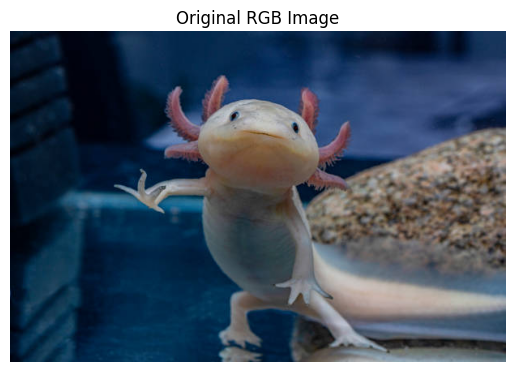

In [2]:
image_path = '../../input.jpg'
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title('Original RGB Image')
plt.axis('off')
plt.show()

In [3]:
def rgb_to_hsi(image):
    image = image.astype(np.float64) / 255.0
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    intensity = (r + g + b) / 3.0
    min_rgb = np.minimum(np.minimum(r, g), b)
    saturation = np.where(intensity != 0, 1 - min_rgb / intensity, 0)

    numerator = 0.5 * ((r - g) + (r - b))
    denominator = np.sqrt((r - g) ** 2 + (r - b) * (g - b))

    hue = np.arccos(np.clip(numerator / (denominator + 1e-6), -1, 1))
    hue = np.where(b <= g, hue, 2 * np.pi - hue)
    hue = hue / (2 * np.pi)

    return hue, saturation, intensity

def hsi_to_rgb(h, s, i):
    h = h * 2 * np.pi

    r = np.zeros_like(h)
    g = np.zeros_like(h)
    b = np.zeros_like(h)

    mask1 = (h >= 0) & (h < 2 * np.pi / 3)
    b[mask1] = i[mask1] * (1 - s[mask1])
    r[mask1] = i[mask1] * (1 + s[mask1] * np.cos(h[mask1]) / np.cos(np.pi / 3 - h[mask1]))
    g[mask1] = 3 * i[mask1] - r[mask1] - b[mask1]

    mask2 = (h >= 2 * np.pi / 3) & (h < 4 * np.pi / 3)
    h2 = h[mask2] - 2 * np.pi / 3
    r[mask2] = i[mask2] * (1 - s[mask2])
    g[mask2] = i[mask2] * (1 + s[mask2] * np.cos(h2) / np.cos(np.pi / 3 - h2))
    b[mask2] = 3 * i[mask2] - r[mask2] - g[mask2]

    mask3 = (h >= 4 * np.pi / 3)
    h3 = h[mask3] - 4 * np.pi / 3
    g[mask3] = i[mask3] * (1 - s[mask3])
    b[mask3] = i[mask3] * (1 + s[mask3] * np.cos(h3) / np.cos(np.pi / 3 - h3))
    r[mask3] = 3 * i[mask3] - g[mask3] - b[mask3]

    return np.stack([r, g, b], axis=2)

hue, saturation, intensity = rgb_to_hsi(image_rgb)

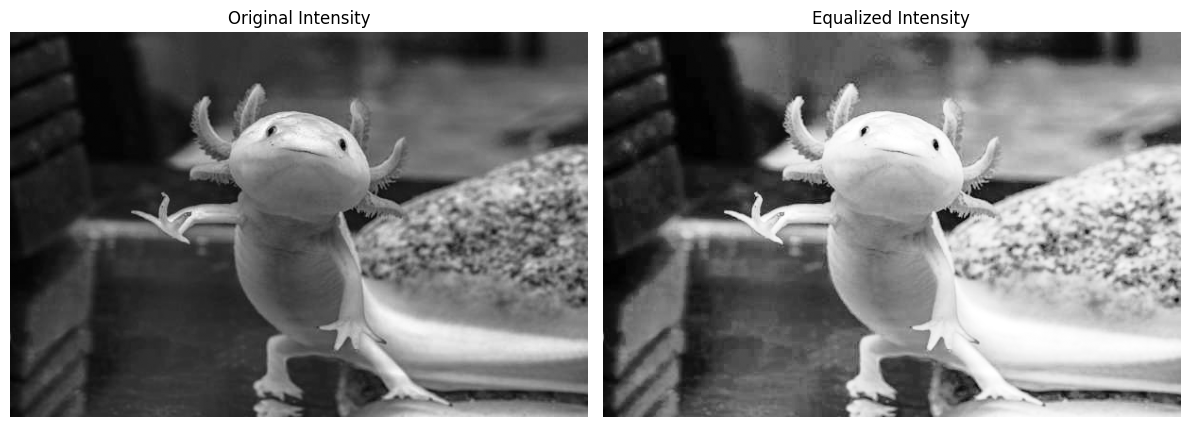

In [4]:
def histogram_equalize(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 1])
    cdf = hist.cumsum()
    cdf_normalized = cdf / cdf[-1]

    equalized = np.interp(image.flatten(), bins[:-1], cdf_normalized)
    return equalized.reshape(image.shape)

intensity_eq = histogram_equalize(intensity)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(intensity, cmap='gray')
plt.title('Original Intensity')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(intensity_eq, cmap='gray')
plt.title('Equalized Intensity')
plt.axis('off')
plt.tight_layout()
plt.show()

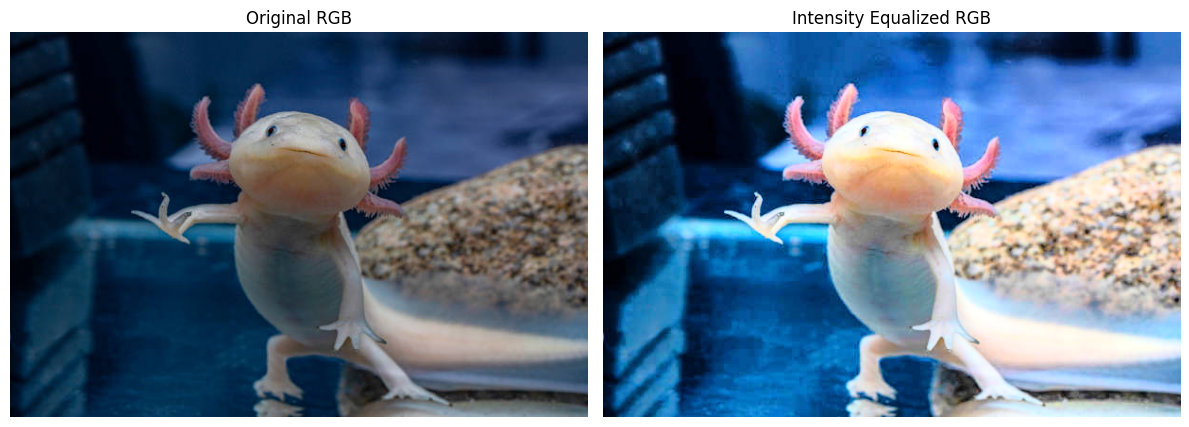

In [5]:
hsi_eq = np.stack([hue, saturation, intensity_eq], axis=2)
rgb_eq = hsi_to_rgb(hue, saturation, intensity_eq)
rgb_eq = np.clip(rgb_eq * 255, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_eq)
plt.title('Intensity Equalized RGB')
plt.axis('off')
plt.tight_layout()
plt.show()